<a href="https://colab.research.google.com/github/Bhargavi9704047224/Traffic_sign_recognition/blob/main/Traffic_sign_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from PIL import Image
import os
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical
from keras.models import Sequential, load_model
from keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
dataset_path = "/content/drive/MyDrive/tsr"

In [6]:
import os
print(os.listdir(dataset_path))

['Meta.csv', 'Test.csv', 'Train.csv', 'Meta', 'Train', 'Test']


In [7]:
import os
print(os.path.exists(dataset_path))

True


In [13]:
train_csv = pd.read_csv(os.path.join(dataset_path, "Train.csv"))

print(train_csv.head())

   Width  Height  Roi.X1  Roi.Y1  Roi.X2  Roi.Y2  ClassId  \
0     27      26       5       5      22      20       20   
1     28      27       5       6      23      22       20   
2     29      26       6       5      24      21       20   
3     28      27       5       6      23      22       20   
4     28      26       5       5      23      21       20   

                             Path  
0  Train/20/00020_00000_00000.png  
1  Train/20/00020_00000_00001.png  
2  Train/20/00020_00000_00002.png  
3  Train/20/00020_00000_00003.png  
4  Train/20/00020_00000_00004.png  


In [17]:
print(os.listdir("/content/drive/MyDrive/tsr/Train")[:10])


['16', '17', '14', '15', '13', '12', '10', '1', '11', '0']


In [19]:
data = []
labels = []

train_path = "/content/drive/MyDrive/tsr/Train"

for class_id in os.listdir(train_path):

    class_folder = os.path.join(train_path, class_id)

    for img_name in os.listdir(class_folder):

        img_path = os.path.join(class_folder, img_name)

        try:
            image = Image.open(img_path).convert("RGB")
            image = image.resize((30, 30))
            image = np.array(image)

            data.append(image)
            labels.append(int(class_id))

        except Exception as e:
            print("Error:", img_path)

In [21]:
#Convert to NumPy arrays
data = np.array(data)
labels = np.array(labels)

print(data.shape)
print(labels.shape)

#Normalize data
data = data / 255.0

#Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    data, labels,
    test_size=0.2,
    random_state=42
)

print(X_train.shape, X_test.shape)

#One-hot encoding
y_train = to_categorical(y_train, 43)
y_test = to_categorical(y_test, 43)

(12970, 30, 30, 3)
(12970,)
(10376, 30, 30, 3) (2594, 30, 30, 3)


In [22]:
#Build CNN model

from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout

model = Sequential()

model.add(Conv2D(32, (5,5), activation='relu', input_shape=(30,30,3)))
model.add(Conv2D(32, (5,5), activation='relu'))
model.add(MaxPool2D(2,2))
model.add(Dropout(0.25))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPool2D(2,2))
model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(43, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
#Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [24]:
#Train model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=5,   # start small
    batch_size=32
)

Epoch 1/5
325/325 ━━━━━━━━━━━━━━━━━━━━ 45s 127ms/step - accuracy: 0.7929 - loss: 0.6897 - val_accuracy: 0.9827 - val_loss: 0.0617
Epoch 2/5
325/325 ━━━━━━━━━━━━━━━━━━━━ 43s 132ms/step - accuracy: 0.9819 - loss: 0.0692 - val_accuracy: 0.9958 - val_loss: 0.0185
Epoch 3/5
325/325 ━━━━━━━━━━━━━━━━━━━━ 42s 129ms/step - accuracy: 0.9876 - loss: 0.0457 - val_accuracy: 0.9961 - val_loss: 0.0125
Epoch 4/5
325/325 ━━━━━━━━━━━━━━━━━━━━ 82s 130ms/step - accuracy: 0.9923 - loss: 0.0299 - val_accuracy: 0.9969 - val_loss: 0.0132
Epoch 5/5
325/325 ━━━━━━━━━━━━━━━━━━━━ 80s 125ms/step - accuracy: 0.9941 - loss: 0.0242 - val_accuracy: 0.9942 - val_loss: 0.0251


In [25]:
# model improvement
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    horizontal_flip=False
)

datagen.fit(X_train)

In [26]:
#IMPROVED CNN MODEL

from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization

model = Sequential()

# Block 1
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(30,30,3)))
model.add(BatchNormalization())
model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPool2D(2,2))
model.add(Dropout(0.25))

# Block 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPool2D(2,2))
model.add(Dropout(0.25))

# Fully Connected
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(43, activation='softmax'))

In [27]:
#BETTER COMPILATION
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [28]:
#TRAINING (WITH AUGMENTATION)
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_test, y_test),
    epochs=15
)

Epoch 1/15
325/325 ━━━━━━━━━━━━━━━━━━━━ 47s 135ms/step - accuracy: 0.7468 - loss: 0.8192 - val_accuracy: 0.6488 - val_loss: 1.2523
Epoch 2/15
325/325 ━━━━━━━━━━━━━━━━━━━━ 44s 136ms/step - accuracy: 0.9419 - loss: 0.1894 - val_accuracy: 0.9800 - val_loss: 0.0536
Epoch 3/15
325/325 ━━━━━━━━━━━━━━━━━━━━ 41s 127ms/step - accuracy: 0.9670 - loss: 0.1031 - val_accuracy: 0.9934 - val_loss: 0.0195
Epoch 4/15
325/325 ━━━━━━━━━━━━━━━━━━━━ 43s 131ms/step - accuracy: 0.9773 - loss: 0.0692 - val_accuracy: 0.9958 - val_loss: 0.0085
Epoch 5/15
325/325 ━━━━━━━━━━━━━━━━━━━━ 44s 136ms/step - accuracy: 0.9822 - loss: 0.0604 - val_accuracy: 0.9988 - val_loss: 0.0033
Epoch 6/15
325/325 ━━━━━━━━━━━━━━━━━━━━ 81s 132ms/step - accuracy: 0.9880 - loss: 0.0433 - val_accuracy: 0.9977 - val_loss: 0.0081
Epoch 7/15
325/325 ━━━━━━━━━━━━━━━━━━━━ 41s 126ms/step - accuracy: 0.9895 - loss: 0.0365 - val_accuracy: 0.9988 - val_loss: 0.0035
Epoch 8/15
325/325 ━━━━━━━━━━━━━━━━━━━━ 45s 138ms/step - accuracy: 0.9880 - loss: 0

In [29]:
#ADD CONFUSION MATRIX (VERY IMPORTANT FOR RESUME)

from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred_classes))

82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        47
           1       0.99      1.00      1.00       435
          10       1.00      1.00      1.00       411
          11       1.00      1.00      1.00       243
          12       1.00      1.00      1.00       414
          13       1.00      1.00      1.00       445
          14       1.00      1.00      1.00       147
          15       1.00      1.00      1.00       135
          16       1.00      1.00      1.00        92
          17       1.00      1.00      1.00       225

    accuracy                           1.00      2594
   macro avg       1.00      0.99      1.00      2594
weighted avg       1.00      1.00      1.00      2594



In [30]:
model.save("traffic_sign_best_model.h5")

In [31]:
'''REAL-TIME TRAFFIC SIGN DETECTION (WEB CAM)

You will:

Load your trained CNN model
Open webcam
Detect traffic sign live
Predict class in real-time'''


'REAL-TIME TRAFFIC SIGN DETECTION (WEB CAM)\n\nYou will:\n\nLoad your trained CNN model\nOpen webcam\nDetect traffic sign live\nPredict class in real-time'

In [32]:
#import libraries
import cv2
import numpy as np
from tensorflow.keras.models import load_model
from PIL import Image

In [41]:
#LOAD YOUR TRAINED MODEL
import numpy as np
import cv2
from tensorflow.keras.models import load_model
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt


In [40]:
model = load_model("traffic_sign_best_model.h5")

In [45]:
uploaded = files.upload()

Saving Screenshot 2026-04-02 192929.png to Screenshot 2026-04-02 192929.png


In [46]:
for img_name in uploaded.keys():

    image = Image.open(img_name).convert("RGB")
    image = image.resize((30, 30))

    img_array = np.array(image) / 255.0
    img_array = img_array.reshape(1, 30, 30, 3)

    prediction = model.predict(img_array)
    class_id = np.argmax(prediction)

    print("Predicted Class ID:", class_id)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
Predicted Class ID: 11


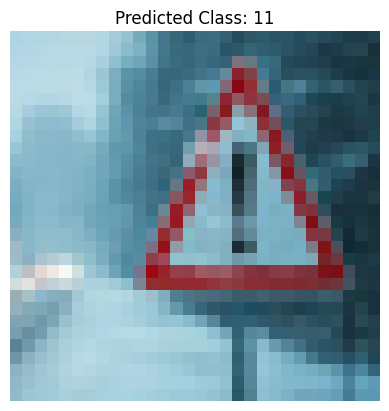

In [47]:
plt.imshow(image)
plt.title(f"Predicted Class: {class_id}")
plt.axis("off")
plt.show()